# Assignment: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

1. A model is linear if it is linear in the coefficients, not necessarily in the variables. You can include things like x squared or log(x) and it is still linear because those just act like new variables.

$$\hat{y} = b_0 + b_1 x_1 + b_2 x_2 + ... + b_L x_L$$

Each $b$ enters multiplicatively. Furthermore, transformations of the regressors don't make the model nonlinear. You can include $x^2$, $\log(x)$, or $\text{arcsinh}(x)$ as features, and the model is still linear because those are just new variables that still enter through their coefficients linearly. A truly nonlinear model would have coefficients entering in a nonlinear way, like $y = b_1^{x_1}$.

2. - Without an intercept: Each dummy coefficient is the mean of $y$ for that category.

- With an intercept: The intercept is the mean of $y$ for the omitted/reference category, and without an intercept, each dummy just gives the average y for that group. With an intercept, the intercept is the average for the reference group, and the other coefficients show how much each group differs from it.

if you include an intercept and all dummies, you have perfect multicollinearity so you must either drop the intercept or drop one dummy.


3. OLS can predict values less than 0 or greater than 1 which doesn't make sense for probabilities. SO if you're predicting a binary 0/1 outcome, predicted values should represent probabilities bounded in $[0, 1]$.

4. Some signs:
- High $R^2$ on training data but low  $R^2$ on test data
- Low RMSE on training but high RMSE on test
- Using too many variables relative to sample size, giving the model too many opportunities to exaggerate noise in the data

5. Each coefficient $b_k$ represents the effect of $x_k$ on $y$ after removing the variation in $x_k$ explained by all the other variables.

First, regress $x_k$ on all the other $x$ variables. Save the residuals $r_x$.

Second, regress $y$ on $r_x$. The slope from this regression equals the multiple regression coefficient $b_k$.

Multicollinearity is when the $x$ variables are highly correlated with each other. After step 1, the residuals $r_x$ have very little variation left with most of $x_k$'s variation was "explained away" by the other variables. Then with tiny residuals, the step 2 regression becomes unstable.

6. Since a linear model is linear in the coefficients you can create new features that capture nonlinear patterns:

- Polynomial features: Include $x^2, x^3, ..., x^K$ to capture curvature
- Interaction terms: Multiply two variables together
- Log or arcsinh transformations: $\log(x)$ or $\text{arcsinh}(x)$

7. - Intercept The predicted value of $y$ when all other variables equal zero.

- Slope coefficient: A one-unit increase in $x_k$ is associated with a $b_k$ unit change in $\hat{y}$, holding all other variables constant.

- Dummy coefficient: The difference in predicted $y$ between that category and the reference category holding all else constant.

- Dummy coefficient: The coefficient is the mean value of $y$ for that category

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

                     Price  Review Scores Rating
Neighbourhood                                   
Manhattan       183.664286             91.801496
Staten Island   146.166667             90.843750
Brooklyn        127.747378             92.363497
Queens           96.857233             91.549057
Bronx            75.276498             91.654378

Most expensive borough on average: Manhattan


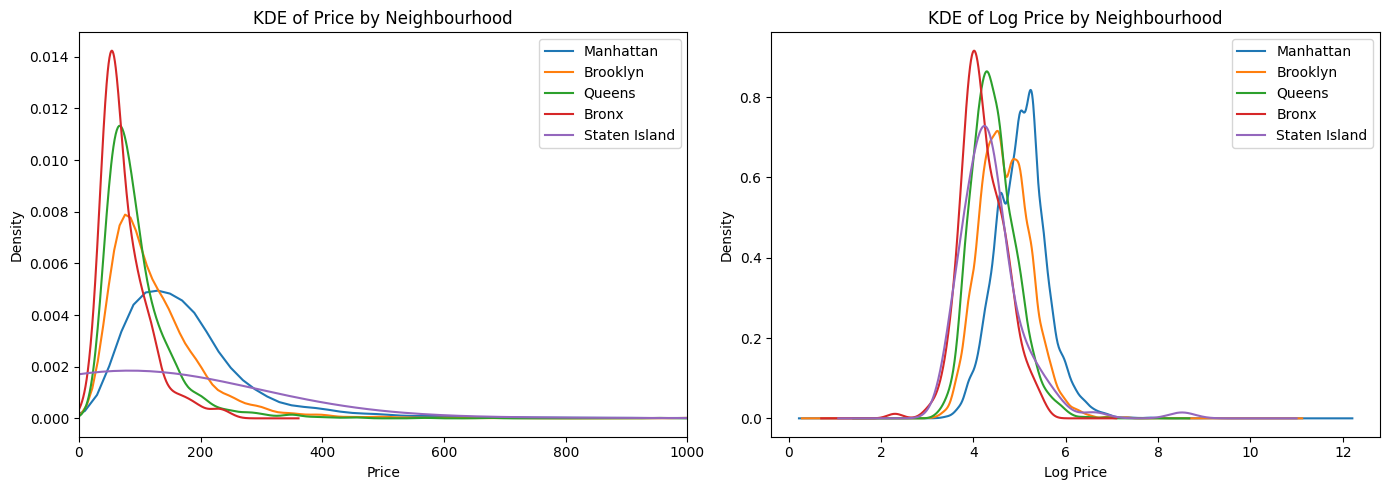

               Regression Coefficient  Group Mean
Bronx                       75.276498   75.276498
Brooklyn                   127.747378  127.747378
Manhattan                  183.664286  183.664286
Queens                      96.857233   96.857233
Staten Island              146.166667  146.166667
The coefficients exactly equal the group means. When you regress a continuous variable on one categorical variable without an intercept, each coefficient equals the average of $y$ for that category.
Reference (dropped) category: Bronx

Intercept: 75.2765
Mean price of Bronx: 75.2765

               Coefficient
Brooklyn         52.470881
Manhattan       108.387789
Queens           21.580735
Staten Island    70.890169
The intercept equals the mean price of the reference category (Bronx). Each coefficient is the difference in mean price between that borough and the reference (Bronx). To recover the no-intercept coefficients: add the intercept to each coefficient. The reference category's coeffi

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error

df = pd.read_csv('/content/Q1_clean.csv')
df.head()

# Average prices and scores by neighbourhood
avg_table = df.groupby('Neighbourhood ')[['Price', 'Review Scores Rating']].mean()
print(avg_table.sort_values('Price', ascending=False))
print()
print("Most expensive borough on average:", avg_table['Price'].idxmax())


# KDE of Price and Log Price by Neighbourhood
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for nbhd in df['Neighbourhood '].unique():
    subset = df[df['Neighbourhood '] == nbhd]
    subset['Price'].plot.kde(ax=axes[0], label=nbhd)
axes[0].set_title('KDE of Price by Neighbourhood')
axes[0].set_xlabel('Price')
axes[0].set_xlim(0, 1000)
axes[0].legend()

df['log_price'] = np.log(df['Price'])
for nbhd in df['Neighbourhood '].unique():
    subset = df[df['Neighbourhood '] == nbhd]
    subset['log_price'].plot.kde(ax=axes[1], label=nbhd)
axes[1].set_title('KDE of Log Price by Neighbourhood')
axes[1].set_xlabel('Log Price')
axes[1].legend()

plt.tight_layout()
plt.show()

# Create dummies keep ALL columns (no drop_first)
dummies = pd.get_dummies(df['Neighbourhood '], dtype=float)

# Regression without intercept
reg_no_int = LinearRegression(fit_intercept=False).fit(dummies, df['Price'])

# Compare coefficients to group means
coef_df = pd.DataFrame({
    'Regression Coefficient': reg_no_int.coef_,
    'Group Mean': [df[df['Neighbourhood '] == col]['Price'].mean() for col in dummies.columns]
}, index=dummies.columns)

print(coef_df)




print("The coefficients exactly equal the group means. When you regress a continuous variable on one categorical variable without an intercept, each coefficient equals the average of $y$ for that category.")

# Drop first dummy (reference category)
dummies_drop = pd.get_dummies(df['Neighbourhood '], drop_first=True, dtype=float)
ref_category = sorted(df['Neighbourhood '].unique())[0]
print(f"Reference (dropped) category: {ref_category}")
print()

# Regression WITH intercept
reg_w_int = LinearRegression(fit_intercept=True).fit(dummies_drop, df['Price'])

print(f"Intercept: {reg_w_int.intercept_:.4f}")
print(f"Mean price of {ref_category}: {df[df['Neighbourhood '] == ref_category]['Price'].mean():.4f}")
print()

coef_df2 = pd.DataFrame({
    'Coefficient': reg_w_int.coef_
}, index=dummies_drop.columns)
print(coef_df2)


print(
"The intercept equals the mean price of the reference category (Bronx). Each coefficient is the difference in mean price between that borough and the reference (Bronx). To recover the no-intercept coefficients: add the intercept to each coefficient. The reference category's coefficient is just the intercept itself.")


dummies_nbhd = pd.get_dummies(df['Neighbourhood '], drop_first=True, dtype=float)
X = pd.concat([df[['Review Scores Rating']], dummies_nbhd], axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg4 = LinearRegression().fit(X_train, y_train)
y_pred = reg4.predict(X_test)

print(f"Test R²:  {r2_score(y_test, y_pred):.4f}")
print(f"Test RMSE: {root_mean_squared_error(y_test, y_pred):.4f}")
print(f"\nCoefficient on Review Scores Rating: {reg4.coef_[0]:.4f}")
print()

# Most expensive neighbourhood
coefs4 = dict(zip(X_train.columns, reg4.coef_))
nbhd_coefs = {k: v for k, v in coefs4.items() if k != 'Review Scores Rating'}
most_exp = max(nbhd_coefs, key=nbhd_coefs.get)
print(f"Most expensive borough: {most_exp}")


dummies_prop = pd.get_dummies(df['Property Type'], drop_first=True, dtype=float)
X2 = pd.concat([df[['Review Scores Rating']], dummies_nbhd, dummies_prop], axis=1)

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)

reg5 = LinearRegression().fit(X2_train, y2_train)
y2_pred = reg5.predict(X2_test)

print(f"Test R²:  {r2_score(y2_test, y2_pred):.4f}")
print(f"Test RMSE: {root_mean_squared_error(y2_test, y2_pred):.4f}")
print(f"\nCoefficient on Review Scores Rating: {reg5.coef_[0]:.4f}")

# Most expensive property type
coefs5 = dict(zip(X2_train.columns, reg5.coef_))
prop_coefs = {k: v for k, v in coefs5.items()
              if k not in ['Review Scores Rating'] + list(dummies_nbhd.columns)}
most_exp_prop = max(prop_coefs, key=prop_coefs.get)
print(f"\nMost expensive property type: {most_exp_prop} (coef = {prop_coefs[most_exp_prop]:.2f})")




Each coefficient shows how that variable relates to price while holding the others fixed. When we add Property Type

1. The coefficient on Review Scores Rating now captures the effect of ratings on price after removing variation explained by both Neighbourhood and Property Type.
2. If Property Type is correlated with both ratings and price, then omitting it caused the rating coefficient to pick up some of the property type effect
3. The change in the coefficient reflects the fact that the pure relationship between ratings and price is different once you control for property type

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

Original shape: (976, 11)

         Make_Year   Mileage_Run  Seating_Capacity         Price
count   976.000000    976.000000        976.000000  9.760000e+02
mean   2016.963115  41571.195697          5.095287  7.410195e+05
std       2.818742  24390.995134          0.446224  3.673234e+05
min    2011.000000   1117.000000          4.000000  1.880000e+05
25%    2015.000000  22676.750000          5.000000  4.757500e+05
50%    2017.000000  37570.500000          5.000000  6.665000e+05
75%    2019.000000  57421.250000          5.000000  8.830000e+05
max    2022.000000  99495.000000          8.000000  2.941000e+06
Price clipped to [-135125, 1493875]
Cleaned shape: (976, 13)

         Make_Year   Mileage_Run  Seating_Capacity         Price         Age  \
count   976.000000    976.000000        976.000000  9.760000e+02  976.000000   
mean   2016.963115  41571.195697          5.095287  7.220832e+05    7.036885   
std       2.818742  24390.995134          0.446224  3.114130e+05    2.818742   
min   

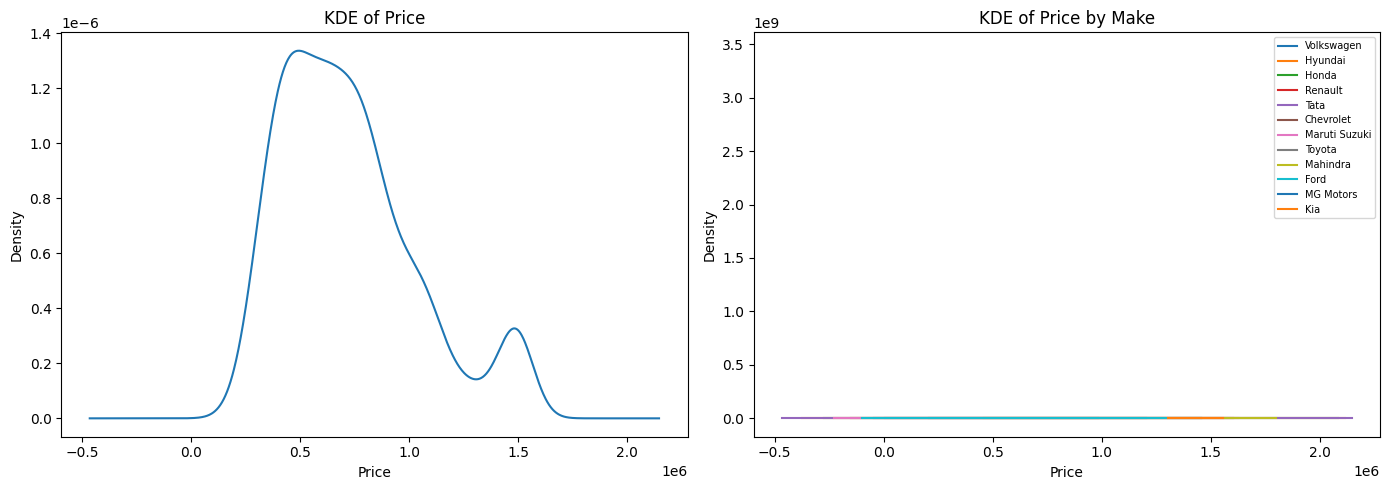


Most expensive brands (by mean price):
Make
MG Motors    1.493875e+06
Kia          1.478266e+06
Jeep         1.442906e+06
Mahindra     1.100167e+06
Tata         9.560978e+05
Name: Price, dtype: float64
Train: (780, 46), Test: (196, 46)
=== Model 1: Numeric Only ===
  Train R²:  0.3569
  Train RMSE: 252609
  Test R²:   0.3274
  Test RMSE:  241670

=== Model 2: Categorical Only ===
  Train R²:  0.7371
  Train RMSE: 161519
  Test R²:   0.6792
  Test RMSE:  166887

=== Model 3: all Features Combined ===
  Train R²:  0.8425
  Train RMSE: 125021
  Test R²:   0.8168
  Test RMSE:  126130

Combined model performs best 
Degree 1: Train R²=0.8425, Test R²=0.8168, Train RMSE=125021, Test RMSE=126130, n_features=46
Degree 2: Train R²=0.8482, Test R²=0.8173, Train RMSE=122715, Test RMSE=125947, n_features=56
Degree 3: Train R²=0.3995, Test R²=0.3616, Train RMSE=244107, Test RMSE=235439, n_features=76
Degree 4: Train R²=0.4099, Test R²=0.3465, Train RMSE=241989, Test RMSE=238208, n_features=111
Degr

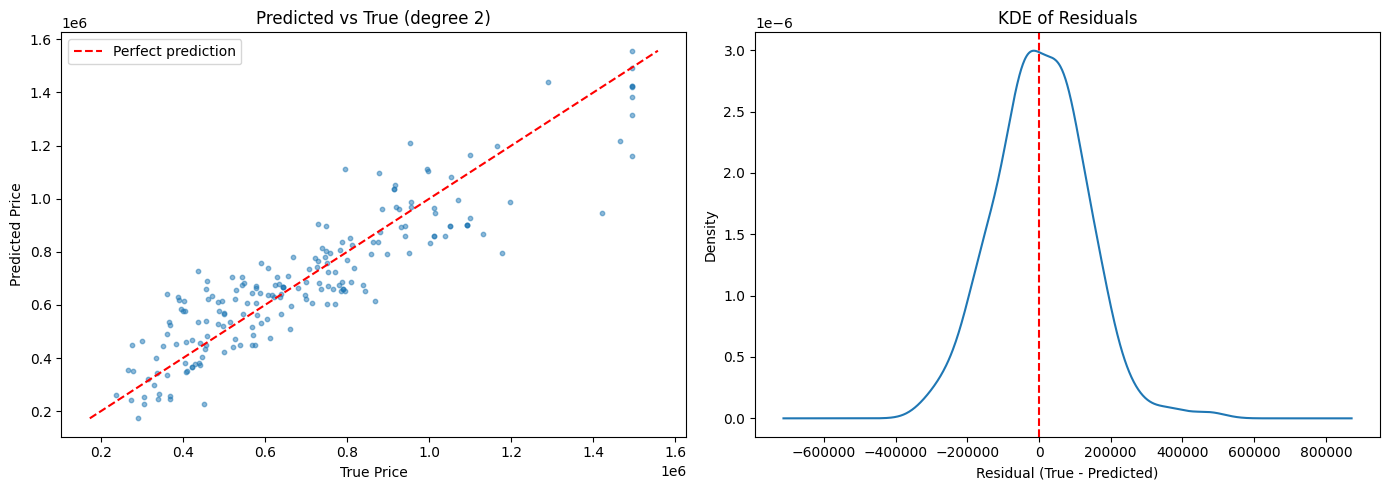

Mean residual: 3876.94
Std of residuals: 125887.33


In [22]:
cars = pd.read_csv('/content/cars_hw.csv')
cars = cars.drop(columns=['Unnamed: 0'])
print("Original shape:", cars.shape)
print()
print(cars.describe())

# Cleaning
# 1. Create Age variable
cars['Age'] = 2024 - cars['Make_Year']

# 2. Windsorize Price outliers (IQR method)
Q1 = cars['Price'].quantile(0.25)
Q3 = cars['Price'].quantile(0.75)
IQR = Q3 - Q1
cars['Price'] = cars['Price'].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
print(f"Price clipped to [{Q1 - 1.5*IQR:.0f}, {Q3 + 1.5*IQR:.0f}]")

# 3. Windsorize Mileage_Run outliers
Q1m = cars['Mileage_Run'].quantile(0.25)
Q3m = cars['Mileage_Run'].quantile(0.75)
IQRm = Q3m - Q1m
cars['Mileage_Run'] = cars['Mileage_Run'].clip(Q1m - 1.5*IQRm, Q3m + 1.5*IQRm)

# 4. Log transform of Price
cars['log_price'] = np.log(cars['Price'])

print(f"Cleaned shape: {cars.shape}")
print()
print(cars.describe())


#q3.2
print(cars['Price'].describe())
print()
print("Prices by Make:")
print(cars.groupby('Make')['Price'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cars['Price'].plot.kde(ax=axes[0])
axes[0].set_title('KDE of Price')
axes[0].set_xlabel('Price')

for make in cars['Make'].unique():
    subset = cars[cars['Make'] == make]
    if len(subset) > 5:
        subset['Price'].plot.kde(ax=axes[1], label=make)
axes[1].set_title('KDE of Price by Make')
axes[1].set_xlabel('Price')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

print("\nMost expensive brands (by mean price):")
print(cars.groupby('Make')['Price'].mean().sort_values(ascending=False).head(5))

#q3.3
y_cars = cars['Price']

numeric_cols = ['Make_Year', 'Mileage_Run', 'Seating_Capacity', 'Age']
cat_cols = ['Make', 'Color', 'Body_Type', 'No_of_Owners', 'Fuel_Type',
            'Transmission', 'Transmission_Type']

X_num = cars[numeric_cols]
X_cat = pd.get_dummies(cars[cat_cols], drop_first=True, dtype=float)
X_all = pd.concat([X_num, X_cat], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X_all, y_cars, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

#q3.4
# Model 1: Numeric only
reg_num = LinearRegression().fit(X_train[numeric_cols], y_train)
pred_num_train = reg_num.predict(X_train[numeric_cols])
pred_num_test  = reg_num.predict(X_test[numeric_cols])

print("=== Model 1: Numeric Only ===")
print(f"  Train R²:  {r2_score(y_train, pred_num_train):.4f}")
print(f"  Train RMSE: {root_mean_squared_error(y_train, pred_num_train):.0f}")
print(f"  Test R²:   {r2_score(y_test, pred_num_test):.4f}")
print(f"  Test RMSE:  {root_mean_squared_error(y_test, pred_num_test):.0f}")
print()

# Model 2: Categorical only
cat_cols_dummies = [c for c in X_train.columns if c not in numeric_cols]
reg_cat = LinearRegression().fit(X_train[cat_cols_dummies], y_train)
pred_cat_train = reg_cat.predict(X_train[cat_cols_dummies])
pred_cat_test  = reg_cat.predict(X_test[cat_cols_dummies])

print("=== Model 2: Categorical Only ===")
print(f"  Train R²:  {r2_score(y_train, pred_cat_train):.4f}")
print(f"  Train RMSE: {root_mean_squared_error(y_train, pred_cat_train):.0f}")
print(f"  Test R²:   {r2_score(y_test, pred_cat_test):.4f}")
print(f"  Test RMSE:  {root_mean_squared_error(y_test, pred_cat_test):.0f}")
print()

# Model 3: combined
reg_all = LinearRegression().fit(X_train, y_train)
pred_all_train = reg_all.predict(X_train)
pred_all_test  = reg_all.predict(X_test)

print("=== Model 3: all Features Combined ===")
print(f"  Train R²:  {r2_score(y_train, pred_all_train):.4f}")
print(f"  Train RMSE: {root_mean_squared_error(y_train, pred_all_train):.0f}")
print(f"  Test R²:   {r2_score(y_test, pred_all_test):.4f}")
print(f"  Test RMSE:  {root_mean_squared_error(y_test, pred_all_test):.0f}")
print()
print("Combined model performs best ")


#q3.5
from sklearn.preprocessing import PolynomialFeatures

results = []
for deg in range(1, 7):
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    X_num_poly_train = poly.fit_transform(X_train[numeric_cols])
    X_num_poly_test  = poly.transform(X_test[numeric_cols])

    X_poly_train = np.hstack([X_num_poly_train, X_train[cat_cols_dummies].values])
    X_poly_test  = np.hstack([X_num_poly_test,  X_test[cat_cols_dummies].values])

    reg_poly = LinearRegression().fit(X_poly_train, y_train)
    pred_train = reg_poly.predict(X_poly_train)
    pred_test  = reg_poly.predict(X_poly_test)

    r2_tr  = r2_score(y_train, pred_train)
    r2_te  = r2_score(y_test, pred_test)
    rmse_tr = root_mean_squared_error(y_train, pred_train)
    rmse_te = root_mean_squared_error(y_test, pred_test)

    results.append((deg, r2_tr, r2_te, rmse_tr, rmse_te))
    print(f"Degree {deg}: Train R²={r2_tr:.4f}, Test R²={r2_te:.4f}, "
          f"Train RMSE={rmse_tr:.0f}, Test RMSE={rmse_te:.0f}, "
          f"n_features={X_poly_train.shape[1]}")

neg_r2 = [r for r in results if r[2] < 0]
if neg_r2:
    print(f"\nR² goes negative on test set at degree {neg_r2[0][0]}")
else:
    print("\nR² did not go negative in degrees 1-6, but performance drops sharply after degree 2 (overfitting).")

best = max(results, key=lambda x: x[2])
print(f"\nBest polynomial model: degree {best[0]} with Test R²={best[2]:.4f}, Test RMSE={best[4]:.0f}")

#3.6
# Refit best model
best_deg = max(results, key=lambda x: x[2])[0]
poly_best = PolynomialFeatures(degree=best_deg, include_bias=False)
X_num_poly_train = poly_best.fit_transform(X_train[numeric_cols])
X_num_poly_test  = poly_best.transform(X_test[numeric_cols])
X_poly_train = np.hstack([X_num_poly_train, X_train[cat_cols_dummies].values])
X_poly_test  = np.hstack([X_num_poly_test,  X_test[cat_cols_dummies].values])

reg_best = LinearRegression().fit(X_poly_train, y_train)
y_pred_best = reg_best.predict(X_poly_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_best, alpha=0.5, s=10)
mn = min(y_test.min(), y_pred_best.min())
mx = max(y_test.max(), y_pred_best.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', label='Perfect prediction')
axes[0].set_xlabel('True Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'Predicted vs True (degree {best_deg})')
axes[0].legend()

# Residual KDE
residuals = y_test.values - y_pred_best
pd.Series(residuals).plot.kde(ax=axes[1])
axes[1].axvline(0, color='r', linestyle='--')
axes[1].set_title('KDE of Residuals')
axes[1].set_xlabel('Residual (True - Predicted)')

plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.2f}")
print(f"Std of residuals: {residuals.std():.2f}")

- Points roughly cluster along the diagonal
- Residuals are roughly bell-shaped around zero → errors are approximately symmetric and unbiased.
- Strengths: Decent overall fit ($R^2 \approx 0.82$), unbiased predictions, captures the major price drivers.
- Weaknesses: High RMSE (~126K) means individual predictions can be substantially off. The model likely struggles more at extreme price ranges.

Q4
The model is $\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}$, where $z_{ij} = x_{ij} - m_j$ are de-meaned.

partial derivatives:
$$SSE = \sum_{i=1}^N (y_i - b_0 - b_1 z_{i1} - b_2 z_{i2})^2$$

$$\frac{\partial SSE}{\partial b_0} = -2 \sum_{i=1}^N (y_i - b_0 - b_1 z_{i1} - b_2 z_{i2}) = 0$$

$$\frac{\partial SSE}{\partial b_1} = -2 \sum_{i=1}^N z_{i1}(y_i - b_0 - b_1 z_{i1} - b_2 z_{i2}) = 0$$

$$\frac{\partial SSE}{\partial b_2} = -2 \sum_{i=1}^N z_{i2}(y_i - b_0 - b_1 z_{i1} - b_2 z_{i2}) = 0$$


4.3
Define $e_i = y_i - b_0 - b_1 z_{i1} - b_2 z_{i2}$.

From the $b_0$ FOC: $\sum_{i=1}^N e_i = 0 \implies \bar{e} = 0$. The average error is zero.

From the $b_1$ FOC: $\sum_{i=1}^N z_{i1} \, e_i = 0 \implies e \cdot z_1 = 0$

From the $b_2$: $\sum_{i=1}^N z_{i2} \, e_i = 0 \implies e \cdot z_2 = 0$

The error vector is orthogonal to each regressor



From the $b_0$ FOC, divide by $N$:

$$\bar{y} - b_0 - b_1 \underbrace{\bar{z}_1}_{=\,0} - b_2 \underbrace{\bar{z}_2}_{=\,0} = 0$$

Since $z_{ij}$ is de-meaned, $\frac{1}{N}\sum z_{ij} = 0$ by construction. Therefore $b_0^* = \bar{y}$.

Substituting back and using $\sum z_{ij} \cdot \bar{y} = \bar{y} \sum z_{ij} = 0$, the remaining equations simplify to:

$$\sum_{i=1}^N z_{i1} \, y_i = b_1 \sum_{i=1}^N z_{i1}^2 + b_2 \sum_{i=1}^N z_{i1} z_{i2}$$

$$\sum_{i=1}^N z_{i2} \, y_i = b_1 \sum_{i=1}^N z_{i2} z_{i1} + b_2 \sum_{i=1}^N z_{i2}^2$$



4.5
$$\underbrace{\begin{pmatrix} \sum z_{i1}^2 & \sum z_{i1} z_{i2} \\ \sum z_{i2} z_{i1} & \sum z_{i2}^2 \end{pmatrix}}_{A} \underbrace{\begin{pmatrix} b_1 \\ b_2 \end{pmatrix}}_{b} = \underbrace{\begin{pmatrix} \sum z_{i1} y_i \\ \sum z_{i2} y_i \end{pmatrix}}_{C}$$



4.6
Dividing both sides by $N$:

$$\begin{pmatrix} \frac{1}{N}\sum z_{i1}^2 & \frac{1}{N}\sum z_{i1} z_{i2} \\ \frac{1}{N}\sum z_{i2} z_{i1} & \frac{1}{N}\sum z_{i2}^2 \end{pmatrix} \begin{pmatrix} b_1 \\ b_2 \end{pmatrix} = \begin{pmatrix} \frac{1}{N}\sum z_{i1} y_i \\ \frac{1}{N}\sum z_{i2} y_i \end{pmatrix}$$

Since $z_{ij} = x_{ij} - m_j$, these are just sample variances and covariances

$$A = \begin{pmatrix} \text{Var}(x_1) & \text{Cov}(x_1, x_2) \\ \text{Cov}(x_1, x_2) & \text{Var}(x_2) \end{pmatrix}$$

This is the variance-covariance matrix of the regressors.

$$C = \begin{pmatrix} \text{Cov}(x_1, y) \\ \text{Cov}(x_2, y) \end{pmatrix}$$

This is the vector of covariances between each regressor and the outcome.

The optimal coefficients balance two things: (1) how each regressor covaries with $y$, and (2) how the regressors covary with each other. When regressors are uncorrelated ($\text{Cov}(x_1, x_2) = 0$), the matrix $A$ is diagonal and each coefficient equals $\text{Cov}(x_j, y) / \text{Var}(x_j)$ the bivariate regression formula. When regressors are correlated, the off-diagonal terms force the coefficients to adjust for shared variation



**Q4.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.
5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.
6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.